# 1.3 Saving Your Chip Design

Once you've built a design interactively in the GUI (or headlessly), Quantum Metal gives you two ways to persist it:

1. **`design.to_python_script()`** — exports a self-contained Python script that recreates every component, route, and option from scratch. Use this for version control, sharing, batch sweeps, or running headlessly in CI.
2. **GDS export** — renders the final fabrication mask via the GDS renderer. Junctions from an external GDS file are automatically unit-scaled and merged in.

## What this tutorial covers

| Section | What you'll learn |
|---------|------------------|
| Build the design | A realistic 2-qubit chip with charge lines, readout resonators, and wirebond launchers |
| `to_python_script()` | How to export and replay a design as a plain Python file |
| GDS export | How to hand off to the fabrication flow with correct junction placement |

## Prerequisites

This notebook uses `MetalGUI` for visualisation. If you're running headlessly, replace every `gui.rebuild()` call with `qm.view(design)` — see [1.4 Headless quick view](./1.4%20Headless%20quick%20view%20%28no%20Qt%20GUI%29.ipynb) for the full headless workflow.

## Build the design

We'll construct a realistic 2-qubit chip to give `to_python_script()` something worth saving. The design includes:

- **Q1, Q2** — two `TransmonPocketCL` qubits, each with a charge line (`CL`) port and a readout port
- **Bus_Q1_Q2** — a `RoutePathfinder` CPW bus connecting Q1 and Q2 (7 mm total length)
- **Cap_Q1, Cap_Q2** — interdigital capacitors coupling each qubit to its readout resonator
- **Readout_Q1, Readout_Q2** — meandered CPW readout resonators (5 mm and 6 mm)
- **Launch pads** — four `LaunchpadWirebond` pads for wirebond connections to the readout and charge lines
- **Transmission lines** — `RoutePathfinder` CPW lines connecting each launcher to its capacitor or qubit

The `gds_cell_name` option on each qubit (`FakeJunction_01`, `FakeJunction_02`) references the junction cell that will be substituted during GDS export — see the GDS section at the bottom of this notebook.

In [11]:
## Design your chip
from qiskit_metal import designs, MetalGUI

design = designs.DesignPlanar()

gui = MetalGUI(design)

from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL

options = {
    "pos_x": "0.7mm",
    "pos_y": "0mm",
    "connection_pads": {
        "readout": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": 1,
            "loc_H": 1,
        },
        "bus": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": -1,
            "loc_H": -1,
        },
    },
    "chip": "main",
    "pad_gap": "30um",
    "inductor_width": "20um",
    "pad_width": "425 um",
    "pad_height": "90um",
    "pocket_width": "650um",
    "pocket_height": "650um",
    "orientation": "0",
    "make_CL": True,
    "cl_gap": "6um",
    "cl_width": "10um",
    "cl_length": "20um",
    "cl_ground_gap": "6um",
    "cl_pocket_edge": "180",
    "cl_off_center": "50um",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "hfss_inductance": "14nH",
    "hfss_capacitance": 0,
    "hfss_resistance": 0,
    "hfss_mesh_kw_jj": 7e-06,
    "q3d_inductance": "10nH",
    "q3d_capacitance": 0,
    "q3d_resistance": 0,
    "q3d_mesh_kw_jj": 7e-06,
    "gds_cell_name": "FakeJunction_01",
}
Q1 = TransmonPocketCL(
    design,
    name="Q1",
    options=options,
    options_connection_pads={
        "readout": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": 1,
            "loc_H": 1,
        },
        "bus": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": -1,
            "loc_H": -1,
        },
    },
    make=True,
)
Q1.meta = {}


from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL

options = {
    "pos_x": "-0.7mm",
    "pos_y": "0mm",
    "connection_pads": {
        "readout": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": 1,
            "loc_H": 1,
        },
        "bus": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": -1,
            "loc_H": -1,
        },
    },
    "chip": "main",
    "pad_gap": "30um",
    "inductor_width": "20um",
    "pad_width": "425 um",
    "pad_height": "90um",
    "pocket_width": "650um",
    "pocket_height": "650um",
    "orientation": "180",
    "make_CL": True,
    "cl_gap": "6um",
    "cl_width": "10um",
    "cl_length": "20um",
    "cl_ground_gap": "6um",
    "cl_pocket_edge": "180",
    "cl_off_center": "50um",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "hfss_inductance": "12nH",
    "hfss_capacitance": 0,
    "hfss_resistance": 0,
    "hfss_mesh_kw_jj": 7e-06,
    "q3d_inductance": "10nH",
    "q3d_capacitance": 0,
    "q3d_resistance": 0,
    "q3d_mesh_kw_jj": 7e-06,
    "gds_cell_name": "FakeJunction_02",
}
Q2 = TransmonPocketCL(
    design,
    name="Q2",
    options=options,
    options_connection_pads={
        "readout": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": 1,
            "loc_H": 1,
        },
        "bus": {
            "pad_gap": "15um",
            "pad_width": "125um",
            "pad_height": "30um",
            "pad_cpw_shift": "5um",
            "pad_cpw_extent": "25um",
            "cpw_width": "cpw_width",
            "cpw_gap": "cpw_gap",
            "cpw_extend": "100um",
            "pocket_extent": "5um",
            "pocket_rise": "65um",
            "loc_W": -1,
            "loc_H": -1,
        },
    },
    make=True,
)
Q2.meta = {}


from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

options = {
    "pin_inputs": {
        "start_pin": {"component": "Q1", "pin": "bus"},
        "end_pin": {"component": "Q2", "pin": "bus"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0mm",
        "end_straight": "250um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "7mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "anchors": {},
    "advanced": {"avoid_collision": "true"},
    "step_size": "0.25mm",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "0.8550176727053895 mm",
}
Bus_Q1_Q2 = RoutePathfinder(design, name="Bus_Q1_Q2", options=options, type="CPW")
Bus_Q1_Q2.meta = {}


from qiskit_metal.qlibrary.lumped.cap_3_interdigital import Cap3Interdigital

options = {
    "layer": "1",
    "trace_width": "10um",
    "finger_length": "40um",
    "pocket_buffer_width_x": "10um",
    "pocket_buffer_width_y": "30um",
    "pos_x": "2.5mm",
    "pos_y": "0.25mm",
    "orientation": "90",
}
Cap_Q1 = Cap3Interdigital(
    design, name="Cap_Q1", options=options, component_template=None, make=True
)
Cap_Q1.meta = {}


from qiskit_metal.qlibrary.lumped.cap_3_interdigital import Cap3Interdigital

options = {
    "layer": "1",
    "trace_width": "10um",
    "finger_length": "40um",
    "pocket_buffer_width_x": "10um",
    "pocket_buffer_width_y": "30um",
    "pos_x": "-2.5mm",
    "pos_y": "-0.25mm",
    "orientation": "-90",
}
Cap_Q2 = Cap3Interdigital(
    design, name="Cap_Q2", options=options, component_template=None, make=True
)
Cap_Q2.meta = {}


from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

options = {
    "pin_inputs": {
        "start_pin": {"component": "Q1", "pin": "readout"},
        "end_pin": {"component": "Cap_Q1", "pin": "a"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0.325mm",
        "end_straight": "125um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "5mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "meander": {"spacing": "200um", "asymmetry": "-50um"},
    "snap": "true",
    "prevent_short_edges": "true",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "5.000000000000001 mm",
}
Readout_Q1 = RouteMeander(design, name="Readout_Q1", options=options, type="CPW")
Readout_Q1.meta = {}


from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

options = {
    "pin_inputs": {
        "start_pin": {"component": "Q2", "pin": "readout"},
        "end_pin": {"component": "Cap_Q2", "pin": "a"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0.325mm",
        "end_straight": "125um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "6mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "meander": {"spacing": "200um", "asymmetry": "-50um"},
    "snap": "true",
    "prevent_short_edges": "true",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "5.999999999999999 mm",
}
Readout_Q2 = RouteMeander(design, name="Readout_Q2", options=options, type="CPW")
Readout_Q2.meta = {}


from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

options = {
    "layer": "1",
    "trace_width": "cpw_width",
    "trace_gap": "cpw_gap",
    "lead_length": "25um",
    "pos_x": "3.5mm",
    "pos_y": "0um",
    "orientation": "180",
}
Launch_Q1_Read = LaunchpadWirebond(
    design, name="Launch_Q1_Read", options=options, component_template=None, make=True
)
Launch_Q1_Read.meta = {}


from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

options = {
    "layer": "1",
    "trace_width": "cpw_width",
    "trace_gap": "cpw_gap",
    "lead_length": "25um",
    "pos_x": "-3.5mm",
    "pos_y": "0um",
    "orientation": "0",
}
Launch_Q2_Read = LaunchpadWirebond(
    design, name="Launch_Q2_Read", options=options, component_template=None, make=True
)
Launch_Q2_Read.meta = {}


from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

options = {
    "layer": "1",
    "trace_width": "cpw_width",
    "trace_gap": "cpw_gap",
    "lead_length": "25um",
    "pos_x": "1.35mm",
    "pos_y": "-2.5mm",
    "orientation": "90",
}
Launch_Q1_CL = LaunchpadWirebond(
    design, name="Launch_Q1_CL", options=options, component_template=None, make=True
)
Launch_Q1_CL.meta = {}


from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

options = {
    "layer": "1",
    "trace_width": "cpw_width",
    "trace_gap": "cpw_gap",
    "lead_length": "25um",
    "pos_x": "-1.35mm",
    "pos_y": "2.5mm",
    "orientation": "-90",
}
Launch_Q2_CL = LaunchpadWirebond(
    design, name="Launch_Q2_CL", options=options, component_template=None, make=True
)
Launch_Q2_CL.meta = {}


from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

options = {
    "pin_inputs": {
        "start_pin": {"component": "Launch_Q1_Read", "pin": "tie"},
        "end_pin": {"component": "Cap_Q1", "pin": "b"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0mm",
        "end_straight": "150um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "7mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "anchors": {},
    "advanced": {"avoid_collision": "true"},
    "step_size": "0.25mm",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "1.0750176727053897 mm",
}
TL_Q1 = RoutePathfinder(design, name="TL_Q1", options=options, type="CPW")
TL_Q1.meta = {}


from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

options = {
    "pin_inputs": {
        "start_pin": {"component": "Launch_Q2_Read", "pin": "tie"},
        "end_pin": {"component": "Cap_Q2", "pin": "b"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0mm",
        "end_straight": "150um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "7mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "anchors": {},
    "advanced": {"avoid_collision": "true"},
    "step_size": "0.25mm",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "1.0750176727053897 mm",
}
TL_Q2 = RoutePathfinder(design, name="TL_Q2", options=options, type="CPW")
TL_Q2.meta = {}


from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

options = {
    "pin_inputs": {
        "start_pin": {"component": "Launch_Q1_CL", "pin": "tie"},
        "end_pin": {"component": "Q1", "pin": "Charge_Line"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0mm",
        "end_straight": "150um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "7mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "anchors": {},
    "advanced": {"avoid_collision": "true"},
    "step_size": "0.25mm",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "2.610508836352695 mm",
}
TL_Q1_CL = RoutePathfinder(design, name="TL_Q1_CL", options=options, type="CPW")
TL_Q1_CL.meta = {}


from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

options = {
    "pin_inputs": {
        "start_pin": {"component": "Launch_Q2_CL", "pin": "tie"},
        "end_pin": {"component": "Q2", "pin": "Charge_Line"},
    },
    "fillet": "99um",
    "lead": {
        "start_straight": "0mm",
        "end_straight": "150um",
        "start_jogged_extension": "",
        "end_jogged_extension": "",
    },
    "total_length": "7mm",
    "chip": "main",
    "layer": "1",
    "trace_width": "cpw_width",
    "anchors": {},
    "advanced": {"avoid_collision": "true"},
    "step_size": "0.25mm",
    "hfss_wire_bonds": False,
    "q3d_wire_bonds": False,
    "trace_gap": "cpw_gap",
    "_actual_length": "2.610508836352695 mm",
}
TL_Q2_CL = RoutePathfinder(design, name="TL_Q2_CL", options=options, type="CPW")
TL_Q2_CL.meta = {}


gui.rebuild()

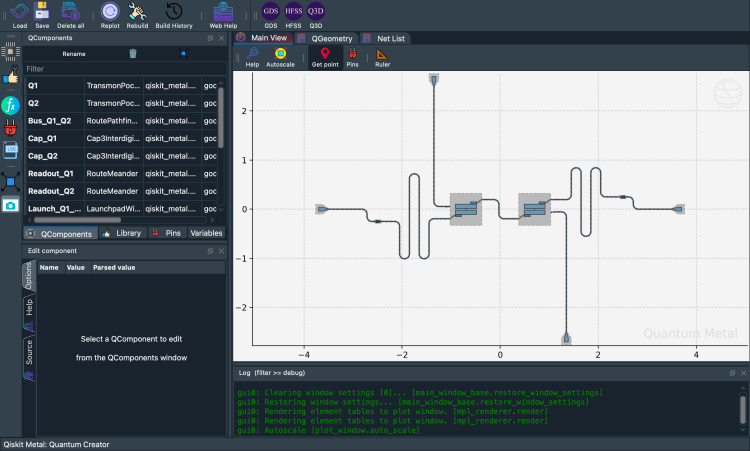

In [2]:
gui.autoscale()
gui.screenshot()

## Headless view with `qm.view()`

The Qt GUI above is optional. `qm.view(design)` renders the same geometry to a standard matplotlib `Figure` with no Qt dependency — it works in any Jupyter kernel, CI runner, or plain script.

The `components` parameter limits the render to a named subset, which makes it easy to spotlight a single qubit inside a larger design:

In [3]:
# MetalGUI initialises PySide6 which can switch matplotlib to the Qt
# backend — plt.subplots() would open a Qt window instead of an inline
# figure. Force Agg (static) rendering for the rest of this notebook.
%matplotlib inline


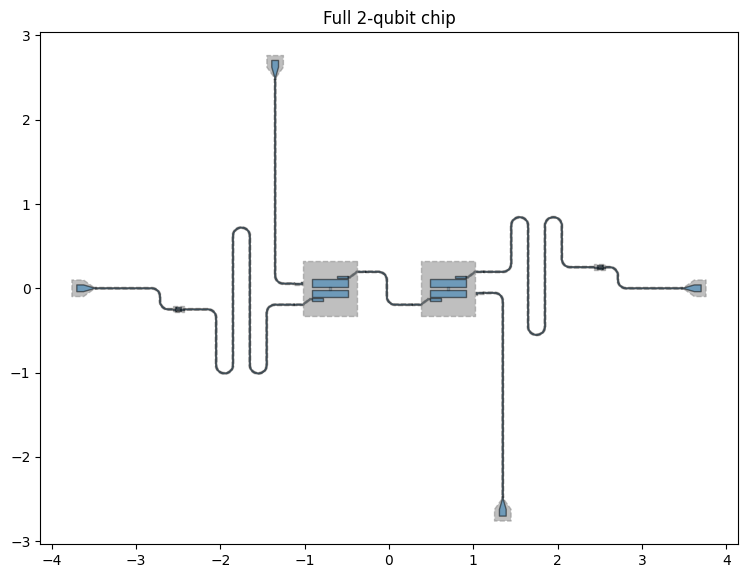

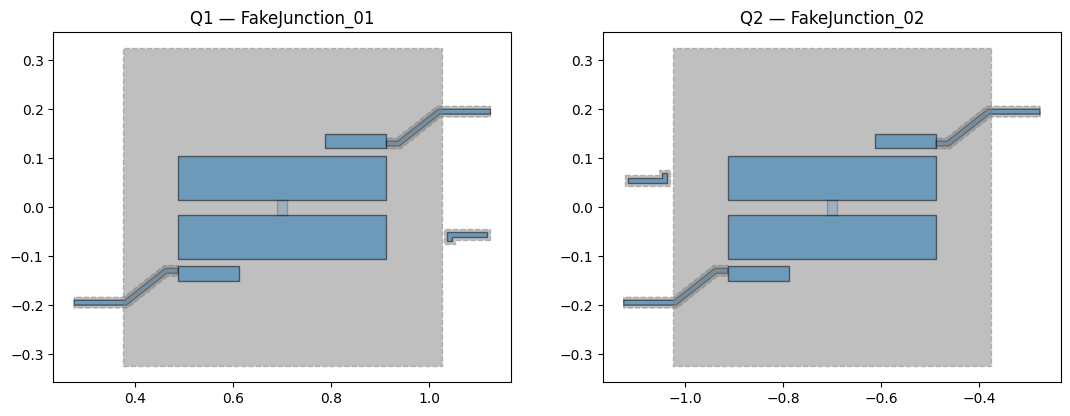

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import qiskit_metal as qm

# Full chip — all 14 components
fig_full = qm.view(design, figsize=(9, 9), title="Full 2-qubit chip")

# Side-by-side: highlight each qubit individually
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
qm.view(design, components=["Q1"], title="Q1 — FakeJunction_01", ax=axes[0])
qm.view(design, components=["Q2"], title="Q2 — FakeJunction_02", ax=axes[1])
plt.tight_layout()
plt.close(fig)

display(fig_full)
display(fig)

In [5]:
design.to_python_script()

"\nfrom qiskit_metal.qlibrary.lumped.cap_3_interdigital import Cap3Interdigital\n\nfrom qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond\n\nfrom qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder\n\nfrom qiskit_metal.qlibrary.tlines.meandered import RouteMeander\n\nfrom qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL\n\nfrom qiskit_metal import designs, MetalGUI\n\ndesign = designs.DesignPlanar()\n\ngui = MetalGUI(design)\n\n\n\n            # WARNING\n#options_connection_pads failed to have a value\nQ1 = TransmonPocketCL(\ndesign,\nname='Q1',\noptions={'cl_pocket_edge': '180',\n 'connection_pads': {'bus': {'cpw_extend': '100um',\n                             'cpw_gap': 'cpw_gap',\n                             'cpw_width': 'cpw_width',\n                             'loc_H': -1,\n                             'loc_W': -1,\n                             'pad_cpw_extent': '25um',\n                             'pad_cpw_shift': '5um',

## Saving with `to_python_script()`

`design.to_python_script()` serialises the entire design state — every component, every option, every route — into a self-contained Python script. Running that script recreates the design identically, with no dependency on the original notebook session.

**When to use it:**
- **Version control** — commit the `.py` file alongside your notebook; diffs are readable
- **Sharing** — send the script to a collaborator who can reproduce the exact design
- **Headless / batch** — run the script in CI or a parameter sweep without launching the GUI
- **Long-term archiving** — the script is plain Python, readable years later without notebook tooling

The output prints to the cell below. Copy it into the cell underneath and run it to verify it reproduces your design cleanly.

### Replay the saved script

Copy the output from the cell above into a fresh code cell (or a `.py` file) and run it. It should rebuild the full design without any of the intermediate cells above.

You can also save it directly to a file:

```python
import pathlib

script = design.to_python_script()          # returns the script as a string
pathlib.Path("my_chip_design.py").write_text(script)
print("Saved to my_chip_design.py")
```

Then replay from the command line:

```bash
python my_chip_design.py
```

> **Tip:** the script is deterministic — running it twice produces the same geometry. This makes it safe to use as a fixture in automated tests or as input to a parameter sweep.

## Exporting to GDS

`to_python_script()` captures your design intent; GDS export produces the fabrication mask. The GDS renderer handles junction placement, ground-plane cheesing, and layer assignment.

```python
gds = design.renderers.gds

# Point to a GDS file containing your Josephson junction cells.
# The file can use any unit (µm, nm, mm) — the renderer auto-scales.
gds.options.path_filename = "../resources/Fake_Junctions.GDS"

# Control whether cheese/no-cheese geometry appears in the output.
# {1: False} = process layer 1 but suppress cheese holes from the file.
# Using Dict(main={}) omits the layer entirely and triggers a warning.
gds.options.cheese.view_in_file    = Dict(main={1: False})
gds.options.no_cheese.view_in_file = Dict(main={1: False})

gds.export_to_gds("my_chip.gds")
```

After export, inspect the result:

```python
import gdstk

lib = gdstk.read_gds("my_chip.gds")

# show=True embeds an SVG preview directly in this cell output.
# Increase scale for a larger chip; increase width to fill the cell.
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)
```

### Junction units

The qubit components in this design use `gds_cell_name` to name the junction placeholder:

| Qubit | `gds_cell_name` |
|-------|----------------|
| Q1 | `FakeJunction_01` |
| Q2 | `FakeJunction_02` |

These names must match cells inside the GDS file pointed to by `path_filename`. The renderer reads the file's `unit` field and rescales all junction geometry automatically — a junction file in nm, µm, or any other unit will land at the correct physical size. See **1.2 Quick start → Render to GDS** for a full walkthrough including layer options and the debug summary tool.

### What's next

- **1.4 Headless quick view** — run and visualise this design without the Qt GUI
- **2 From components to chip** — multi-qubit designs, CPW routing, and design variables
- **3 Renderers** — HFSS, Q3D, GDS, and gmsh/Elmer in depth

In [12]:
from qiskit_metal import MetalGUI, Dict, open_docs

gds = design.renderers.gds

# Point to a GDS file containing your Josephson junction cells.
# The file can use any unit (µm, nm, mm) — the renderer auto-scales.
gds.options.path_filename = "../resources/Fake_Junctions.GDS"

# Control whether cheese/no-cheese geometry appears in the output.
# {1: False} = process layer 1 but suppress cheese holes from the file.
# Using Dict(main={}) omits the layer entirely and triggers a warning.
gds.options.cheese.view_in_file    = Dict(main={1: False})
gds.options.no_cheese.view_in_file = Dict(main={1: False})

gds.export_to_gds("my_chip.gds")

10:21PM 29s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [15]:
import gdstk

lib = gdstk.read_gds("my_chip.gds")

# show=True embeds an SVG preview directly in this cell output.
# Increase scale for a larger chip; increase width to fill the cell.
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)


=== GDS LIBRARY SUMMARY ===
name:      library
unit:      0.001
precision: 1e-09
cells:     7

CELLS:
  - TOP                            geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main                       geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main_1                     geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - ground_main_1                  geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - my_other_junction              geom=True bbox=((-0.015, -0.0015), (0.015, 0.0015))
  - FakeJunction_02                geom=True bbox=((-0.015, -0.0015), (0.015, 0.0015))
  - FakeJunction_01                geom=True bbox=((-0.015, -0.001503), (0.015, 0.0015))

LAYER / DATATYPE USAGE:
  layer  dtype   polys   paths
  -----  -----   -----   -----
      1      0      39       0
      1     10      28       0
      1     11      42       0
     53      0      13       0
     54      0       3       0

lib.layers_and_datatypes():
  (layer=1, datatype=0)
  (layer=1, datatype=10)
  (lay

### GDS layer legend

The renderer writes geometry across several **layer / datatype** pairs.
The layer number matches the `layer` option on each component (default `1`).
The datatype encodes how the geometry was produced:

| Layer | Datatype | Content |
|-------|----------|---------|
| 1 | 0 | **Final metal pattern** — post-boolean result (chip outline, ground plane, qubit pockets merged into a single mask) |
| 1 | 10 | **Component polygons** — individual pad, pocket, and junction-extension-pad outlines before the boolean merge |
| 1 | 11 | **CPW traces** — `FlexPath` geometry for routes, transmission lines, and connectors |
| 53 | 0 | **Junction primary layer** — polygons from the imported junction GDS file (`FakeJunction_01/02`) |
| 54 | 0 | **Junction secondary layer** — second contact layer from the same junction GDS file |

> **Layers 53 and 54 are whatever layers your junction file uses.** If you supply
> your own junction GDS, its layer numbers will appear here instead. Use KLayout's
> layer panel (right-hand side) to toggle each layer on/off and identify them.

The `plot_gds_zoom` panels below colour each `(layer, datatype)` pair distinctly,
making it easy to see where the junction sits relative to the qubit pads.


### Zooming into junction pads in GDS

`debug_summarize_gds_library` gives a chip-level overview. To inspect individual
junctions at fabrication scale, `gds.plot_gds_zoom` clips a small window out of
the flattened GDS and renders it with matplotlib — no KLayout required.

It works by calling `top.get_polygons(depth=None)` to flatten the full cell
hierarchy, filtering to a bounding box around your target, then drawing each
polygon coloured by `(layer, datatype)`.

> **Matplotlib backend note:** `MetalGUI` earlier in this notebook initialises
> PySide6, which can silently switch matplotlib to the `Qt6Agg` backend.
> With that backend active, `plt.subplots()` opens a Qt window instead of
> rendering inline. The `%matplotlib inline` cell below resets to the static
> `Agg` backend. This is expected any time Qt and matplotlib share a kernel;
> it is not a bug in `plot_gds_zoom`.


In [16]:
# Reset to the static Agg backend so plots render inline.
# Needed because MetalGUI (used above) initialises PySide6 which can
# switch matplotlib to Qt6Agg. See the note in the markdown cell above.
%matplotlib inline


In [ ]:
import matplotlib.pyplot as plt

# Zoom into each qubit — 200 µm window centred on the junction.
# Q1 sits at (0.70,  0) mm (orientation   0°) → junction cell rotated  90° → vertical
# Q2 sits at (−0.70, 0) mm (orientation 180°) → junction cell rotated −90° → vertical
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("GDS junction pad zoom — 200 µm window", fontsize=13)

gds.plot_gds_zoom(
    lib, center_mm=(0.70, 0.0), span_mm=0.10,
    title="Q1 — FakeJunction_01 at (0.7, 0) mm",
    ax=axes[0],
)
gds.plot_gds_zoom(
    lib, center_mm=(-0.70, 0.0), span_mm=0.10,
    title="Q2 — FakeJunction_02 at (−0.7, 0) mm",
    ax=axes[1],
)

plt.tight_layout()
# plt.close(fig)
# fig

## Viewing your GDS file

Once you have a `.gds` file, you'll want to inspect it visually — zoom into junction pads, verify layer colours, check that routes don't collide. Several free tools can do this on every platform.

---

### KLayout (recommended)

[KLayout](https://www.klayout.de) is the industry-standard open-source GDS/OASIS viewer and editor. It handles multi-layer designs, has a Python scripting console, and runs on **Windows, macOS, and Linux**.

**Install:**

| Platform | Method |
|----------|---------|
| **macOS** | `brew install --cask klayout` — or download the `.dmg` from [klayout.de/build.html](https://www.klayout.de/build.html) |
| **Windows** | Download the `.exe` installer from [klayout.de/build.html](https://www.klayout.de/build.html) |
| **Linux** | `.rpm` / `.deb` packages available, or `conda install -c conda-forge klayout` |

**Open your file:**

```bash
# From the terminal — opens KLayout with the file loaded
klayout my_chip.gds
```

Or launch KLayout and use **File → Open**.

**Key things to check:**
- **Layer panel** (right side) — toggle layers on/off to isolate metal, junctions, cheese holes
- **Ruler tool** (`R`) — measure distances in design units
- **Zoom to fit** (`F`) — see the full chip at once
- **Zoom into junction pads** — verify physical size matches your design (30 µm × 3 µm for the fake junctions here)

---

### Quick in-notebook preview (no install needed)

You already have `gdstk` and the `debug_summarize_gds_library` tool. For a fast sanity check without leaving Jupyter:

```python
import gdstk
lib = gdstk.read_gds("my_chip.gds")
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)
```

This embeds an SVG overview directly in the cell output and saves with the notebook. Good for a quick geometry and layer check; use KLayout for detailed inspection.

---

### Other free viewers

| Tool | Platform | Notes |
|------|----------|-------|
| [gdstk](https://heitzmann.github.io/gdstk/) | Python (all platforms) | Programmatic; `cell.write_svg()` for per-cell previews |
| [Magic VLSI](http://opencircuitdesign.com/magic/) | Linux / macOS | Full DRC + extraction; steeper learning curve |
| [GDS3D](https://github.com/trilomix/GDS3D) | Windows / Linux | 3D visualisation of GDS layers |
